In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open(f"../scripts/_cache/resnet18_imagenet_2_per_class_stability_vs_smoothing.json") as f:
    resnet18_saved = json.load(f)

with open(f"../scripts/_cache/resnet50_imagenet_2_per_class_stability_vs_smoothing.json") as f:
    resnet50_saved = json.load(f)

with open(f"../scripts/_cache/vit_imagenet_2_per_class_stability_vs_smoothing.json") as f:
    vit_saved = json.load(f)

with open(f"../scripts/_cache/roberta_tweeteval_sentiment_stability_vs_smoothing.json") as f:
    roberta_saved = json.load(f)

In [3]:
# Some meta information for each plot
fs = 12
figsize = (5,3)

In [4]:
x = np.random.randn(7, 100)

In [5]:
np.quantile(x, [0.1, 0.9], axis=0)

array([[-1.73023352, -1.60521062,  0.22597243, -0.37756087, -0.95063889,
        -0.1950726 , -1.18564157, -0.65532845, -0.99313037, -1.21532351,
        -1.3355323 , -0.7518632 , -1.05845913, -0.98326409, -1.33202469,
        -1.19120376, -1.08629447, -1.63244733, -1.21793617, -1.43769706,
        -0.48627045, -0.95081435, -1.19866095, -1.02141653, -1.38387035,
        -1.86713826, -0.35543663, -0.74674812, -0.97876497, -1.4166518 ,
        -1.11924927, -0.97303798, -1.57733564, -1.02586863, -0.87216635,
        -1.08359667, -0.86065535, -0.50630595, -1.19890219, -0.71045738,
        -0.28075981, -1.17745249,  0.00764807, -0.34537851, -0.6189744 ,
        -0.51250932, -0.55162429, -1.15793138, -0.9859122 , -1.28672714,
        -0.55066384, -0.89274752, -1.10840946, -0.29238225, -1.74503998,
        -0.20986166,  0.01377495, -1.0754411 , -0.70728027, -1.99518643,
        -1.06928683, -0.95343571, -1.38686402, -1.3172658 , -0.78523132,
        -1.57560725, -1.49744078, -1.00584401, -0.9

In [6]:
def make_plot(saved, title, legend_loc): #, show_quantiles=False):
    lambda_to_rates = saved["lambda_to_rates"]
    radii = saved["radii"]

    fig, ax = plt.subplots(figsize=(5,3))
    ax.plot(radii, np.median(lambda_to_rates["1.000"], axis=0), label="$\lambda = 1.0$")
    ax.plot(radii, np.median(lambda_to_rates["0.800"], axis=0), label="$\lambda = 0.8$")
    ax.plot(radii, np.median(lambda_to_rates["0.600"], axis=0), label="$\lambda = 0.6$")
    ax.plot(radii, np.median(lambda_to_rates["0.400"], axis=0), label="$\lambda = 0.4$")
    ax.plot(radii, np.median(lambda_to_rates["0.200"], axis=0), label="$\lambda = 0.2$")

    ax.set_ylabel("Stability Rate", fontsize=fs)
    ax.set_xlabel("Perturbation Radius", fontsize=fs)
    ax.tick_params(axis="x", labelsize=fs-2)
    ax.tick_params(axis="y", labelsize=fs-2)
    ax.set_xticks(radii)
    ax.legend(title=title, loc=legend_loc, title_fontsize=fs, fontsize=fs)
    return fig

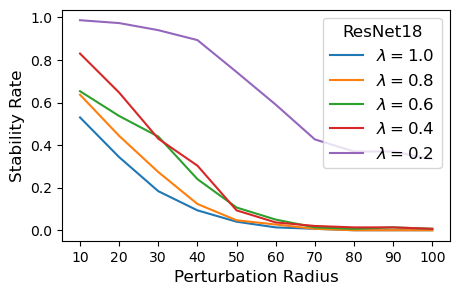

In [7]:
fig = make_plot(resnet18_saved, "ResNet18", legend_loc="upper right")
fig.savefig("_dump/stability_vs_smoothing_resnet18.pdf", bbox_inches="tight")

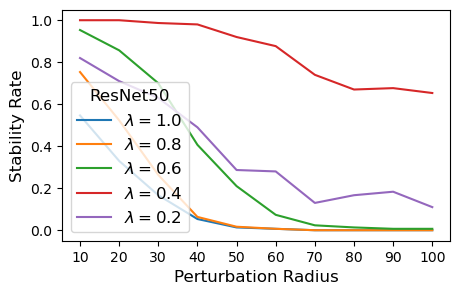

In [8]:
fig = make_plot(resnet50_saved, "ResNet50", legend_loc="lower left")
fig.savefig("_dump/stability_vs_smoothing_resnet50.pdf", bbox_inches="tight")

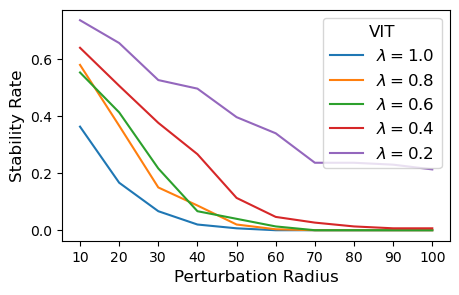

In [9]:
fig = make_plot(vit_saved, "VIT", legend_loc="upper right")
fig.savefig("_dump/stability_vs_smoothing_vit.pdf", bbox_inches="tight")

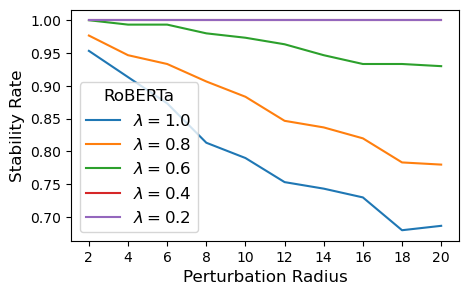

In [10]:
fig = make_plot(roberta_saved, "RoBERTa", legend_loc="lower left")
fig.savefig("_dump/stability_vs_smoothing_roberta.pdf", bbox_inches="tight")

In [11]:
def make_plot_with_quantiles(saved, key, label, title, color):
    lambda_to_rates = saved["lambda_to_rates"]
    radii = saved["radii"]
    fig, ax = plt.subplots(figsize=(4,2))
    data = np.array(lambda_to_rates[key])
    qlo, qhi = np.quantile(data, [0.25, 0.75], axis=0)
    ax.plot(radii, np.median(data, axis=0), label=label, color=color)
    ax.fill_between(radii, qlo, qhi, alpha=0.2, color=color)
    
    ax.set_ylabel("Stability Rate", fontsize=fs)
    ax.set_xlabel("Perturbation Radius", fontsize=fs)
    ax.tick_params(axis="x", labelsize=fs-2)
    ax.tick_params(axis="y", labelsize=fs-2)
    ax.set_xticks(radii)
    ax.legend(title=title, title_fontsize=fs, fontsize=fs)
    return fig

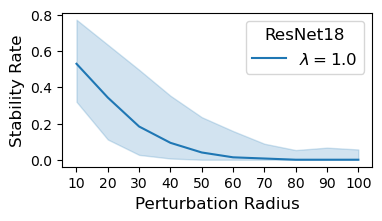

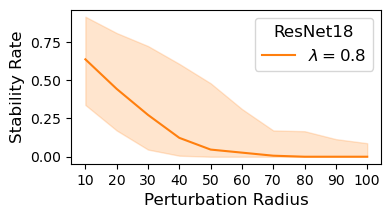

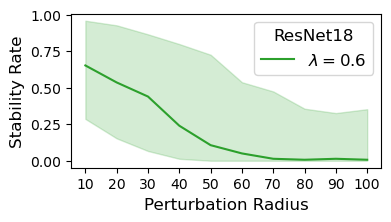

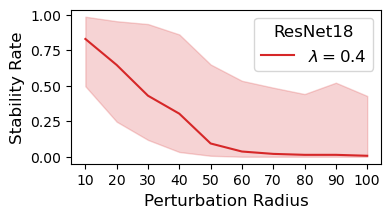

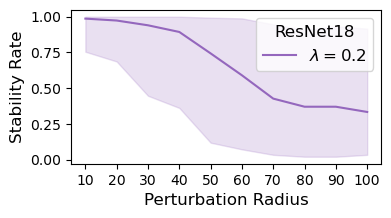

In [12]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
keys = [1.0, 0.8, 0.6, 0.4, 0.2]
for i, k in enumerate(keys):
    fig = make_plot_with_quantiles(resnet18_saved, f"{k:.3f}", f"$\lambda = {k:.1f}$", "ResNet18", color=colors[i])
    fig.savefig(f"_dump/stability_vs_smoothing_resnet18_quantiles_{k:.1f}.pdf", bbox_inches="tight")

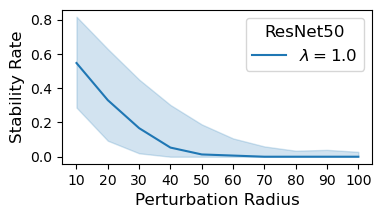

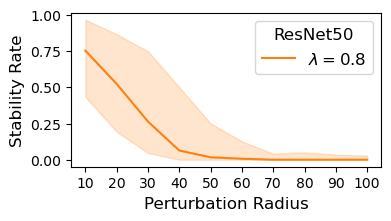

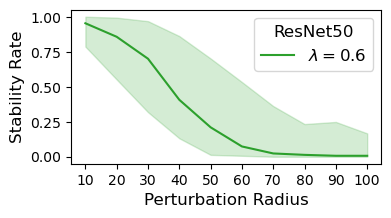

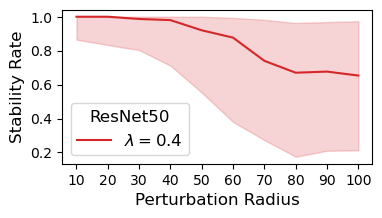

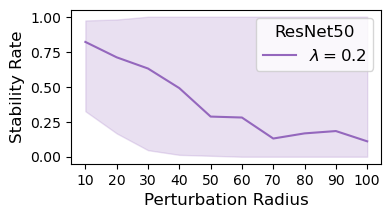

In [13]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
keys = [1.0, 0.8, 0.6, 0.4, 0.2]
for i, k in enumerate(keys):
    fig = make_plot_with_quantiles(resnet50_saved, f"{k:.3f}", f"$\lambda = {k:.1f}$", "ResNet50", color=colors[i])
    fig.savefig(f"_dump/stability_vs_smoothing_resnet50_quantiles_{k:.1f}.pdf", bbox_inches="tight")

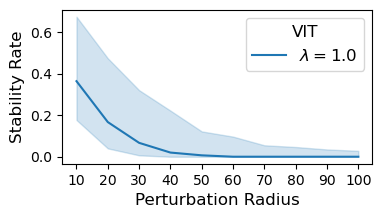

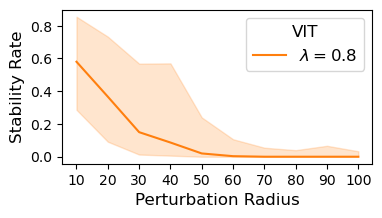

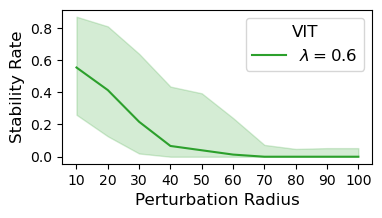

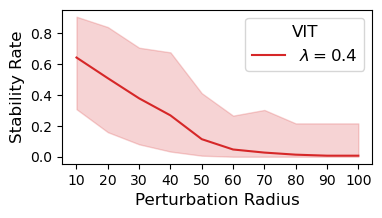

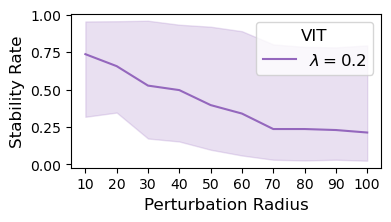

In [14]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
keys = [1.0, 0.8, 0.6, 0.4, 0.2]
for i, k in enumerate(keys):
    fig = make_plot_with_quantiles(vit_saved, f"{k:.3f}", f"$\lambda = {k:.1f}$", "VIT", color=colors[i])
    fig.savefig(f"_dump/stability_vs_smoothing_vit_quantiles_{k:.1f}.pdf", bbox_inches="tight")

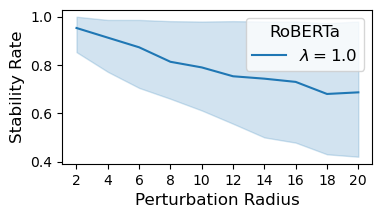

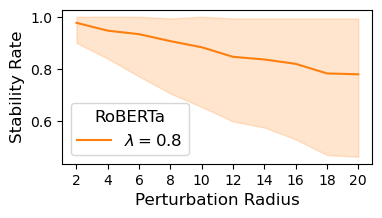

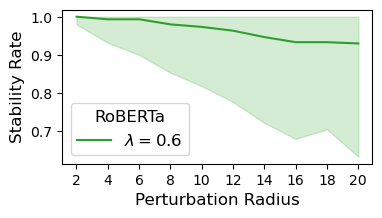

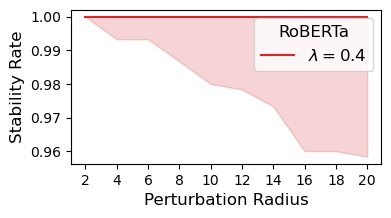

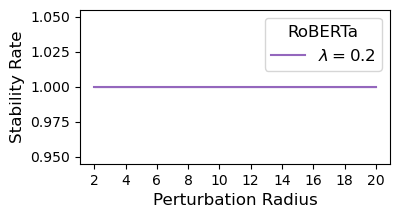

In [15]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
keys = [1.0, 0.8, 0.6, 0.4, 0.2]
for i, k in enumerate(keys):
    fig = make_plot_with_quantiles(roberta_saved, f"{k:.3f}", f"$\lambda = {k:.1f}$", "RoBERTa", color=colors[i])
    fig.savefig(f"_dump/stability_vs_smoothing_roberta_quantiles_{k:.1f}.pdf", bbox_inches="tight")